# Checking motion thresholds

In [1]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append("../../")

import pyaldata as pyal
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import seaborn as sns
import cupy as cp
from sklearn.mixture import GaussianMixture


from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.model_selection import KFold, cross_val_predict, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import r2_score, make_scorer

from tqdm import tqdm

import tools.dimensionality as dim
import tools.decoding as decode
import tools.subspaces as subspaces
import tools.viz.utilityTools as vizutils
import tools.dataTools as dt
from tools.params import colors
import tools.dsp as dsp
import tools.kinematics as kin
import tools.reports as reports

import pickle
import warnings



In [ ]:
data_dir='/data/bnd-data/raw/'
session='M063_2025_03_12_14_00'
combine_time_bins=False

df = pyal.load_pyaldata(data_dir + session[:4] + "/" + session)
df = dsp.preprocess(df, only_trials=False, combine_time_bins=combine_time_bins,
                    repair_time_varying_fields=["MotSen1_X", "MotSen1_Y"])



fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.
fields: ['values_Sol_direction', 'idx_Sol_direction', 'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on'] could not be converted to int.
Repairing columns ['MotSen1_X', 'MotSen1_Y']
Extending index to 47989 in trial: free and id: 710, inserting NaN.
Extending index to 47990 in trial: free and id: 710, inserting NaN.
Extending index to 47991 in trial: free and id: 710, inserting NaN.
Extending index to 47992 in trial: free and id: 710, inserting NaN.
Extending index to 47993 in trial: free and id: 710, inserting NaN.
Extending index to 47994 in trial: free and id: 710, inserting NaN.
Extending index to 47995 in trial: free and id: 710, inserting NaN.
Extending index to 47996 in trial: free and id: 710, inserting NaN.
Extending index to 47997 in trial: free and id: 710, inserting NaN.
Extending index to 47998 in trial: free and id: 710, inserting NaN.
Extending index to 47999 in tria

In [ ]:
df_tr = pyal.select_trials(df, df.trial_name == 'trial')

In [ ]:
df_tr.columns

Index(['animal', 'session', 'trial_id', 'trial_name', 'trial_length',
       'bin_size', 'idx_trial_start', 'idx_trial_end', 'idx_CPI',
       'values_before_camera_trigger', 'idx_before_camera_trigger',
       'idx_motion', 'values_Sol_direction', 'idx_Sol_direction',
       'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on',
       'idx_earthquake_duration', 'idx_session_timer', 'values_MotSen1_X',
       'idx_MotSen1_X', 'values_MotSen1_Y', 'idx_MotSen1_Y', 'hip_center',
       'left_ankle', 'left_ankle_angle', 'left_elbow', 'left_elbow_angle',
       'left_foot', 'left_knee', 'left_knee_angle', 'left_paw',
       'left_shoulder', 'left_wrist', 'left_wrist_angle', 'right_ankle',
       'right_ankle_angle', 'right_elbow', 'right_elbow_angle', 'right_foot',
       'right_knee', 'right_knee_angle', 'right_paw', 'right_shoulder',
       'right_wrist', 'right_wrist_angle', 'shoulder_center', 'tail_base',
       'tail_middle', 'tail_tip', 'all_chan_best', 'all_unit_guide',
       'al

In [ ]:
df_tr.iloc[1].values_Sol_direction

6

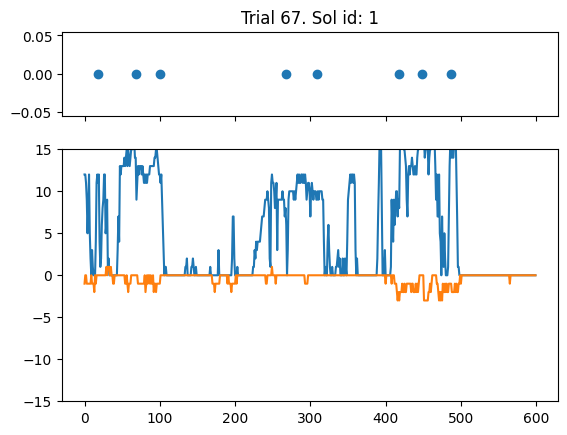

In [ ]:
def plot_mot_sensors_and_thresh(td, tr_idx):
    fig, ax = plt.subplots(2, 1, gridspec_kw={"height_ratios": [1, 3]}, sharex='all')
    motion_events = td.iloc[tr_idx].idx_motion
    # print(motion_events)

    # if len(motion_events) > 0:
    ax[0].plot(motion_events, np.full_like(motion_events, 0), 'o')
    x, y = td.iloc[tr_idx].values_MotSen1_X, td.iloc[tr_idx].values_MotSen1_Y
    ax[1].plot(x)
    ax[1].plot(y)
    ax[1].set_ylim(-15, 15)
    ax[0].set_title(f"Trial {tr_idx}. Sol id: {td.iloc[tr_idx].values_Sol_direction}")


plot_mot_sensors_and_thresh(df_tr, 67)

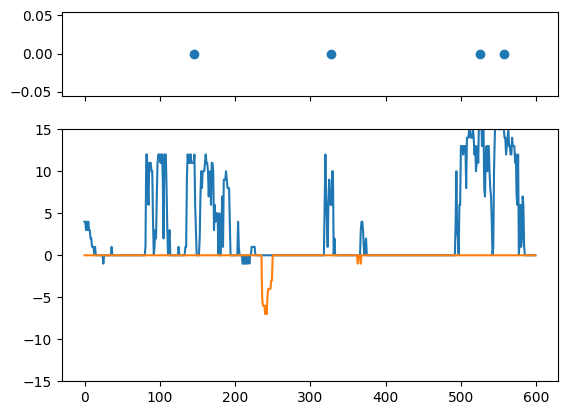

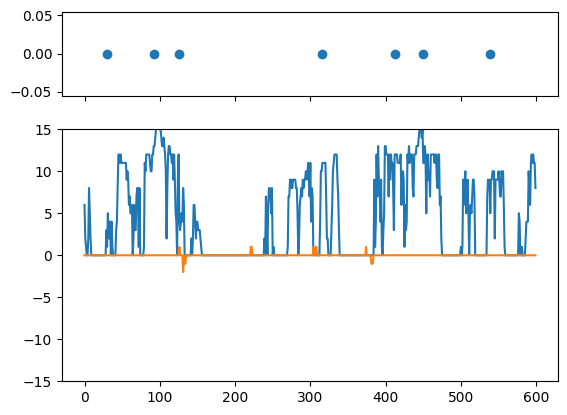

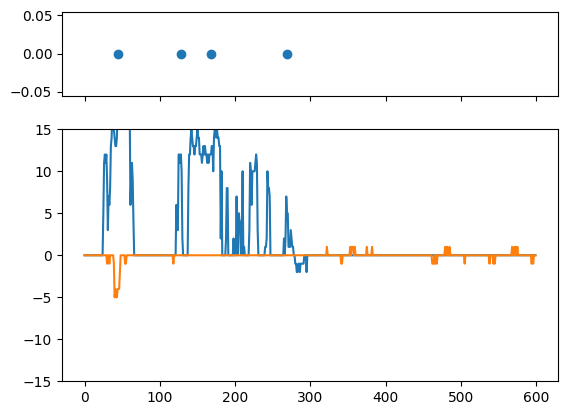

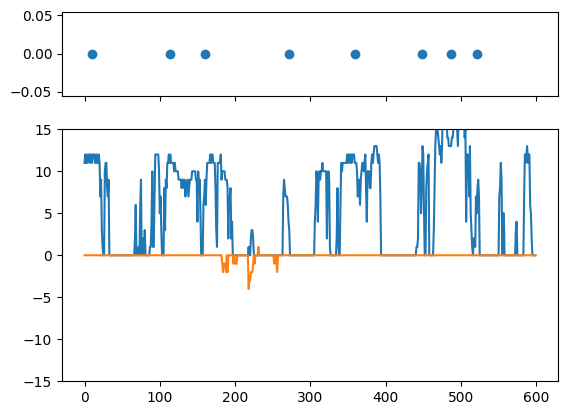

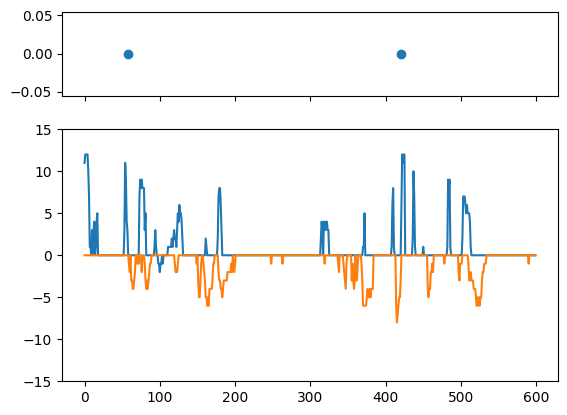

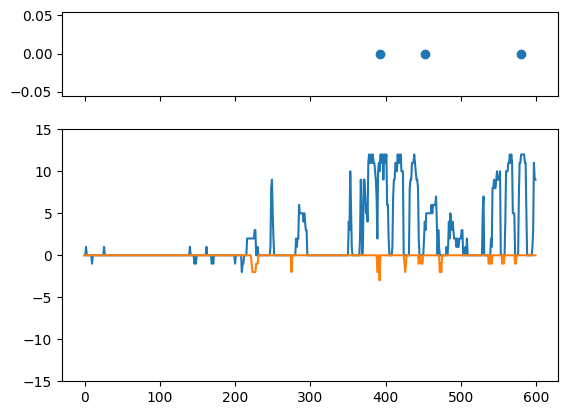

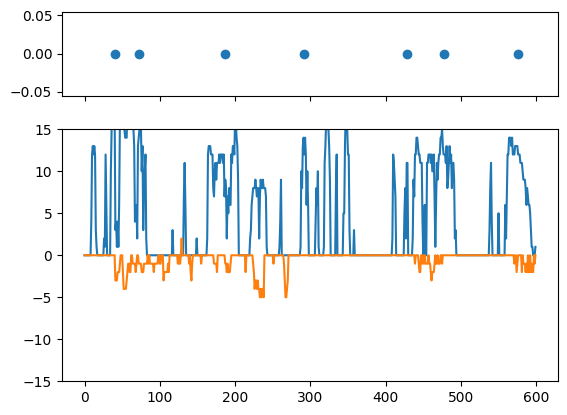

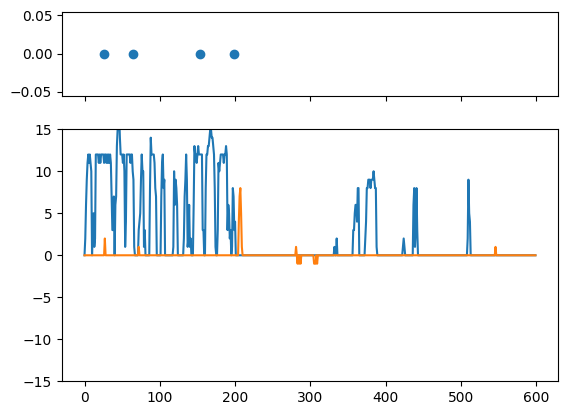

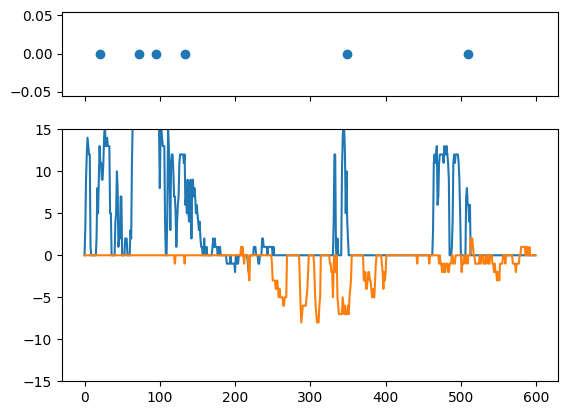

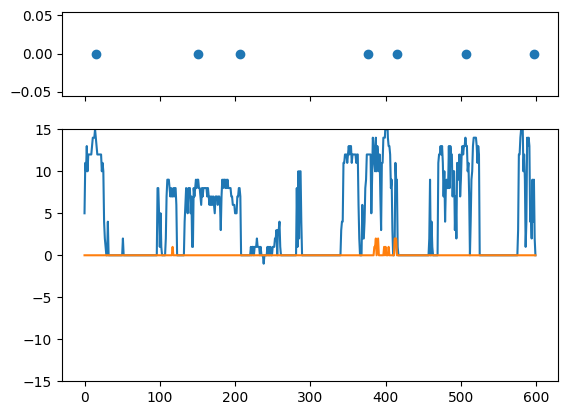

In [ ]:
trials = np.random.randint(0, df_tr.shape[0], 10)
for tr in trials:
    plot_mot_sensors_and_thresh(df_tr, tr)

In [ ]:
df.columns

Index(['animal', 'session', 'trial_id', 'trial_name', 'trial_length',
       'bin_size', 'idx_trial_start', 'idx_trial_end', 'idx_CPI',
       'values_before_camera_trigger', 'idx_before_camera_trigger',
       'idx_motion', 'values_Sol_direction', 'idx_Sol_direction',
       'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on',
       'idx_earthquake_duration', 'idx_session_timer', 'values_MotSen1_X',
       'idx_MotSen1_X', 'values_MotSen1_Y', 'idx_MotSen1_Y', 'hip_center',
       'left_ankle', 'left_ankle_angle', 'left_elbow', 'left_elbow_angle',
       'left_foot', 'left_knee', 'left_knee_angle', 'left_paw',
       'left_shoulder', 'left_wrist', 'left_wrist_angle', 'right_ankle',
       'right_ankle_angle', 'right_elbow', 'right_elbow_angle', 'right_foot',
       'right_knee', 'right_knee_angle', 'right_paw', 'right_shoulder',
       'right_wrist', 'right_wrist_angle', 'shoulder_center', 'tail_base',
       'tail_middle', 'tail_tip', 'SSp_chan_best', 'SSp_unit_guide',
       'SS

NameError: name 'plot_mot_sensors_and_thresh' is not defined

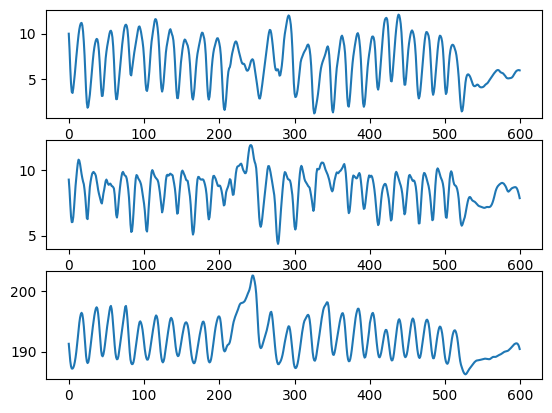

In [ ]:
def plot_kinematics(td, tr_idx, signal):
    fig, ax = plt.subplots(3, 1)
    # motion_events = td.iloc[tr_idx].idx_motion
    # print(motion_events)

    # if len(motion_events) > 0:
    bhv = td.iloc[tr_idx][signal]
    ax[0].plot(bhv[:, 0])
    ax[1].plot(bhv[:, 1])
    ax[2].plot(bhv[:, 2])

    # ax.set_ylim(-15, 15)

trial = 67#88
signal = 'left_knee'

plot_kinematics(df_tr, trial, signal)
plot_mot_sensors_and_thresh(df_tr, trial)

In [ ]:
df_tr.iloc[trial][signal].shape

(600, 3)

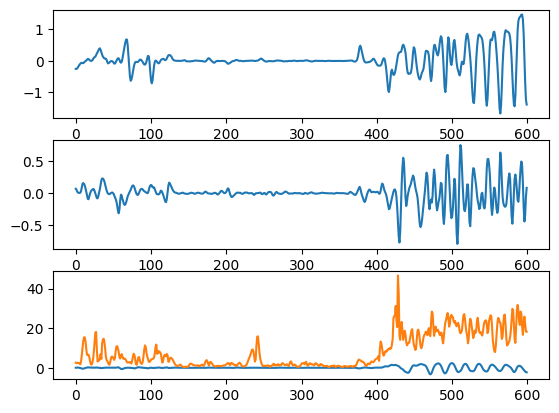

In [ ]:
# def compute_velocity(arr):
#     vel = np.gradient(arr, axis=0)
#     print(vel.shape)

#     return

# compute_velocity(df_tr.iloc[trial][signal])
df = dt.add_bhv(df)
df_tr = pyal.select_trials(df, df.trial_name == 'trial')
vel = np.gradient(df_tr.iloc[88]['bhv'], axis=0)
speed = np.linalg.norm(vel, axis=1)               # (T,)
fig, ax = plt.subplots(3, 1)

ax[0].plot(vel[:, 0])
ax[1].plot(vel[:, 1])
ax[2].plot(vel[:, 2])

plt.plot(speed)

## All speed

In [ ]:
data_dir='/data/bnd-data/raw/'
session='M063_2025_03_14_15_30'
combine_time_bins=False

df = pyal.load_pyaldata(data_dir + session[:4] + "/" + session)
df = dsp.preprocess(df, only_trials=False, combine_time_bins=combine_time_bins,
                    repair_time_varying_fields=["MotSen1_X", "MotSen1_Y"])
df = dt.add_bhv(df)
df_tr = pyal.select_trials(df, df.trial_name == 'trial')


fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.
fields: ['idx_motion', 'values_Sol_direction', 'idx_Sol_direction', 'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on'] could not be converted to int.
fields: ['idx_motion', 'values_Sol_direction', 'idx_Sol_direction', 'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on'] could not be converted to int.
Repairing columns ['MotSen1_X', 'MotSen1_Y']
Extending index to 53999 in trial: free and id: 676, inserting NaN.
Extending index to 53989 in trial: free and id: 676, inserting NaN.
Extending index to 53990 in trial: free and id: 676, inserting NaN.
Extending index to 53991 in trial: free and id: 676, inserting NaN.
Extending index to 53992 in trial: free and id: 676, inserting NaN.
Extending index to 53993 in trial: free and id: 676, inserting NaN.
Extending index to 53994 in trial: free and id: 676, inserting NaN.
Extending index to 53995 in trial: free and id: 676, inserting NaN

In [ ]:
vel = np.gradient(np.concatenate(df_tr.bhv.values), axis=0)
speed = np.linalg.norm(vel, axis=1)  

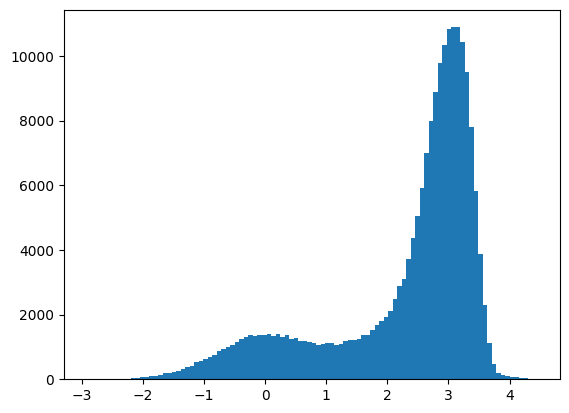

In [ ]:
plt.hist(np.log(speed), bins=100)
plt.show()

In [ ]:
data_dir='/data/bnd-data/raw/'
session='M063_2025_03_12_14_00'
combine_time_bins=False

df = pyal.load_pyaldata(data_dir + session[:4] + "/" + session)
df = dsp.preprocess(df, only_trials=False, combine_time_bins=combine_time_bins,
                    repair_time_varying_fields=["MotSen1_X", "MotSen1_Y"])

df = dt.add_bhv(df)
df_tr = pyal.select_trials(df, df.trial_name == 'trial')

fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.
fields: ['idx_motion'] could not be converted to int.
fields: ['values_Sol_direction', 'idx_Sol_direction', 'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on'] could not be converted to int.
Repairing columns ['MotSen1_X', 'MotSen1_Y']
Extending index to 53999 in trial: free and id: 679, inserting NaN.
Extending index to 53989 in trial: free and id: 679, inserting NaN.
Extending index to 53990 in trial: free and id: 679, inserting NaN.
Extending index to 53991 in trial: free and id: 679, inserting NaN.
Extending index to 53992 in trial: free and id: 679, inserting NaN.
Extending index to 53993 in trial: free and id: 679, inserting NaN.
Extending index to 53994 in trial: free and id: 679, inserting NaN.
Extending index to 53995 in trial: free and id: 679, inserting NaN.
Extending index to 53996 in trial: free and id: 679, inserting NaN.
Extending index to 53997 in trial: free and id

In [ ]:
vel.shape

(203300, 62)

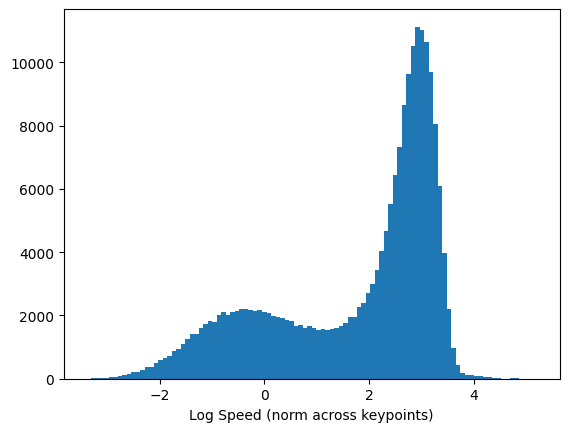

In [ ]:
vel = np.gradient(np.concatenate(df_tr.bhv.values), axis=0)
speed = np.linalg.norm(vel, axis=1)  
plt.hist(np.log(speed), bins=100)
plt.xlabel('Log Speed (norm across keypoints)')
plt.show()

In [ ]:
def assess_bimodality(x, n_init=5, random_state=0):
    g1 = GaussianMixture(n_components=1, covariance_type="full",
                         n_init=n_init, random_state=random_state)
    g2 = GaussianMixture(n_components=2, covariance_type="full",
                         n_init=n_init, random_state=random_state)

    x = x.reshape(-1, 1)
    g1.fit(x)
    g2.fit(x)

    bic1 = g1.bic(x)
    bic2 = g2.bic(x)
    delta_bic = bic1 - bic2  # >0 => K=2 preferred
    print(delta_bic)
    w = g2.weights_.ravel()
    mu = g2.means_.ravel()
    sd = np.sqrt(g2.covariances_.ravel())

    order = np.argsort(mu)
    w, mu, sd = w[order], mu[order], sd[order]
    print("weights:", w)
    print("means:", mu)
    print("sds:", sd)
    d = abs(mu[1]-mu[0]) / np.sqrt(sd[0]**2 + sd[1]**2)
    bimodal_enough = (delta_bic > 10) and (w.min() > 0.10) and (d > 1.9)
    print(bimodal_enough)
    # This is sometimes called a normalised mean 
    # separation (closely related to, but not identical with, Cohen’s d).
    return

In [ ]:
assess_bimodality(np.log(speed))

167976.2918162917
weights: [0.10535305 0.89464695]
means: [1.91615956 3.17656487]
sds: [0.99431209 0.25815171]
False


In [ ]:
assess_bimodality(np.log(speed))

148750.6028719209
weights: [0.38764407 0.61235593]
means: [0.0771781  2.82584188]
sds: [1.19906226 0.42013545]
True


In [ ]:
sessions = [
    # 'M061_2025_03_04_10_00',
    # 'M061_2025_03_05_14_00',
    # 'M061_2025_03_06_14_00',
    # 'M063_2025_03_12_14_00',
    # 'M063_2025_03_13_14_00',
    'M063_2025_03_14_15_30',
    # 'M062_2025_03_19_14_00',
    # 'M062_2025_03_20_14_00',
    # 'M062_2025_03_21_14_00',
    # 'M078_2025_08_05_15_30',
    # 'M078_2025_08_06_15_00',
    # 'M078_2025_08_07_13_30',
]

for session in sessions:
    data_dir='/data/bnd-data/raw/'
    combine_time_bins=False

    df = pyal.load_pyaldata(data_dir + session[:4] + "/" + session)
    df = dsp.preprocess(df, only_trials=False, combine_time_bins=combine_time_bins)
    df = dt.add_bhv(df)
    df_tr = pyal.select_trials(df, df.trial_name == 'trial')
    vel = np.gradient(np.concatenate(df_tr.bhv.values), axis=0)
    speed = np.linalg.norm(vel, axis=1)  

    assess_bimodality(np.log(speed))
    plt.hist(np.log(speed), bins=100)
    plt.xlabel('Log Speed (norm across keypoints)')
    plt.show()

fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.
fields: ['idx_motion', 'values_Sol_direction', 'idx_Sol_direction', 'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on'] could not be converted to int.
fields: ['idx_motion', 'values_Sol_direction', 'idx_Sol_direction', 'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on'] could not be converted to int.
['VAL_spikes', 'SSp_spikes', 'all_spikes', 'MOp_spikes', 'CP_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of VAL_spikes on 99.85228951255539% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of VAL_spikes on 99.85228951255539% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of VAL_spikes on 99.85228951255539% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of VAL_spikes on 99.85228951255539% of trials
  warnings.warn(


Resulting VAL_spikes ephys data shape is (NxT): (260, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (92, 60000)
Resulting all_spikes ephys data shape is (NxT): (38, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (161, 60000)
Resulting CP_spikes ephys data shape is (NxT): (329, 60000)


NameError: name 'assess_bimodality' is not defined

Valley at log-speed: 0.9941436002422495
Linear speed: 9.866056546171107


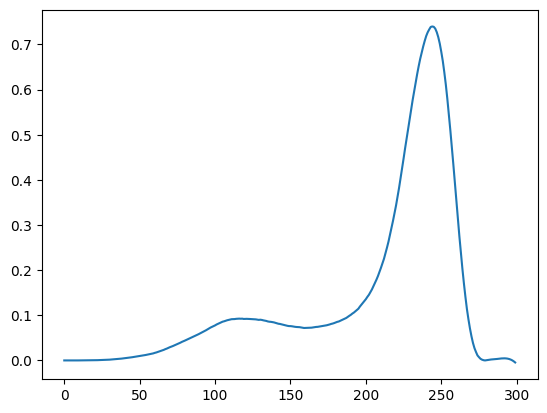

In [ ]:
import numpy as np
from scipy.signal import savgol_filter

def valley_between_means(x, mu1, mu2, bins=300, smooth_win=31, poly=3):
    """
    Find the minimum (valley) of the distribution between two x-values.

    Parameters
    ----------
    x : array-like
        1D data (e.g. log-speed).
    mu1, mu2 : float
        Interval boundaries (means).
    bins : int
        Number of histogram bins.
    smooth_win : int
        Savitzky–Golay window length (must be odd).
    poly : int
        Polynomial order for smoothing.

    Returns
    -------
    x_valley : float
        x-location of minimum density between mu1 and mu2.
    """
    x = np.asarray(x)
    lo, hi = min(mu1, mu2), max(mu1, mu2)

    # Histogram
    hist, edges = np.histogram(x, bins=bins, density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])

    # Smooth histogram
    if smooth_win >= bins:
        smooth_win = bins - 1
    if smooth_win % 2 == 0:
        smooth_win += 1

    hist_s = savgol_filter(hist, smooth_win, poly)

    # Restrict to interval between means
    mask = (centers > lo) & (centers < hi)
    if not np.any(mask):
        raise ValueError("No histogram bins between means.")

    idx = np.argmin(hist_s[mask])
    x_valley = centers[mask][idx]

    plt.plot(hist_s)

    return x_valley

mu1, mu2 = 0.61729383, 2.94553741
x_min = valley_between_means(np.log(speed), mu1, mu2)
print("Valley at log-speed:", x_min)
print("Linear speed:", 10**x_min)

In [ ]:
def count_below_thresh(arr, thresh, win):
    """
    Count number of time points that are part of segments where
    arr < thresh for at least `win` consecutive samples.
    """
    arr = np.asarray(arr)
    mask = arr < thresh

    if win <= 1:
        return int(mask.sum())

    # Find contiguous segments
    padded = np.r_[False, mask, False]
    edges = np.flatnonzero(padded[1:] != padded[:-1])
    starts, ends = edges[0::2], edges[1::2]  # [start, end)

    count = 0
    for s, e in zip(starts, ends):
        if (e - s) >= win:
            count += (e - s)

    return count

import numpy as np

def starts_of_below_thresh_runs(arr, thresh, win):
    """
    Return the start indices of each contiguous segment where arr < thresh
    for at least `win` consecutive samples.

    Parameters
    ----------
    arr : array-like, shape (T,)
    thresh : float
    win : int
        Minimum run length (in samples).

    Returns
    -------
    starts_kept : np.ndarray, shape (n_runs,)
        Start indices of qualifying runs.
    """
    arr = np.asarray(arr)
    mask = arr < thresh

    if win <= 1:
        return np.flatnonzero(mask)

    padded = np.r_[False, mask, False]
    edges = np.flatnonzero(padded[1:] != padded[:-1])
    starts, ends = edges[0::2], edges[1::2]  # half-open [start, end)

    lengths = ends - starts
    starts_kept = starts[lengths >= win]

    return starts_kept

import numpy as np

def starts_of_below_thresh_windows(arr, thresh, win):
    """
    Return start indices i such that arr[i:i+win] are ALL < thresh (sliding window).

    Parameters
    ----------
    arr : array-like, shape (T,)
    thresh : float
    win : int
        Window length (in samples).

    Returns
    -------
    starts : np.ndarray
        Start indices of all valid windows.
        (Length up to T-win+1.)
    """
    arr = np.asarray(arr)
    if win <= 0:
        raise ValueError("win must be >= 1")

    mask = arr < thresh
    if win == 1:
        return np.flatnonzero(mask)

    # counts[j] = number of True values in mask[j:j+win]
    counts = np.convolve(mask.astype(np.int32), np.ones(win, dtype=np.int32), mode="valid")
    return np.flatnonzero(counts == win)


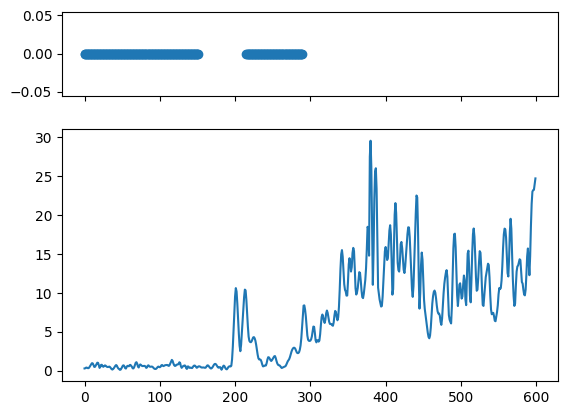

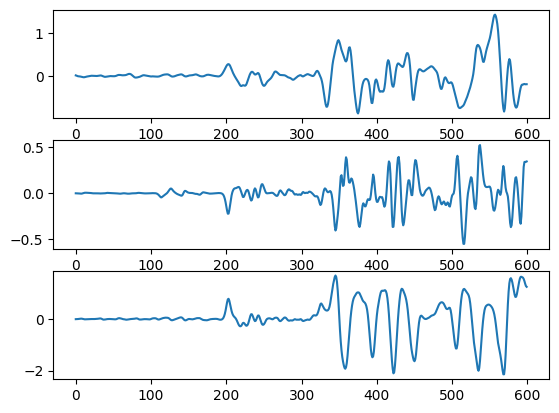

In [ ]:
vel_ = np.gradient(df_tr.iloc[3]['bhv'], axis=0)
speed_ = np.linalg.norm(vel_, axis=1)  
fig, ax = plt.subplots(2, 1, sharex='all', gridspec_kw={"height_ratios": [1, 3]})
starts = starts_of_below_thresh_windows(speed_, 9.8, 50)
ax[0].plot(starts, np.full_like(starts, 0), 'o')
ax[1].plot(speed_)


fig, ax = plt.subplots(3, 1)

ax[0].plot(vel_[:, 0])
ax[1].plot(vel_[:, 1])
ax[2].plot(vel_[:, 2])

In [ ]:
starts

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54])

In [ ]:
np.any((starts > (200 - 100)) & (starts < 200))

False

In [ ]:
def immobile_starts_before_event(bhv_arr, event_onset=200, thresh=9.8, win=40):
    vel = np.gradient(bhv_arr, axis=0)
    speed = np.linalg.norm(vel, axis=1)  
    
    immobile_starts = starts_of_below_thresh_windows(speed, thresh, win)  # indices
    return np.any((immobile_starts > (event_onset - 100)) & (immobile_starts < event_onset))

In [ ]:
df_tr.bhv.values[1].shape

(600, 62)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54]


False

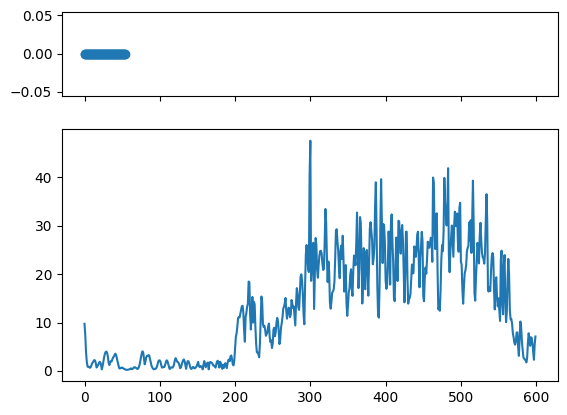

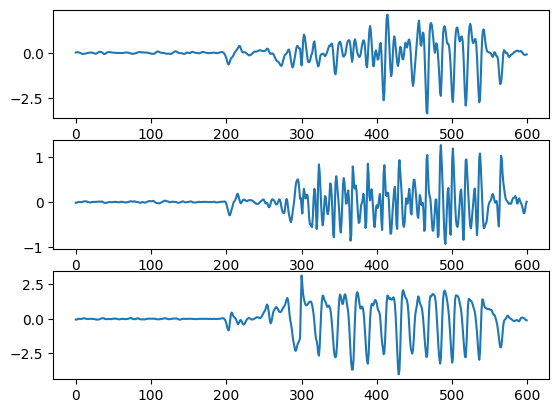

In [ ]:
immobile_starts_before_event(df_tr.iloc[68]['bhv'], event_onset=200, thresh=9.8, win=150)

In [ ]:
for idx, row in enumerate(df_tr.itertuples()):
    flag = immobile_starts_before_event(row.bhv, event_onset=200, thresh=9.8, win=50)
    if flag:
        print(idx)

3
8
11
15
17
23
26
28
31
37
38
40
44
47
48
63
65
66
68
69
73
79
82
84
85
91
92
95
100
101
104
107
113
114
119
123
127
131
134
136
138
141
147
150
152
154
156
159
161
167
171
174
177
185
188
189
191
195
204
212
216
219
225
227
228
232
235
240
243
245
247
249
261
263
265
266
272
278
286
289
292
297
298
300
303
305
308
309
312
314
316
318
319
322
329
333


In [ ]:
initial_count = len(df_tr)

filtered_df = df_tr[df_tr['bhv'].apply(
    lambda arr: ~immobile_starts_before_event(arr, event_onset=200, thresh=9.8, win=50)
)]

dropped_count = initial_count - len(filtered_df)
print(
    f"Dropped {dropped_count} of {initial_count} rows ({dropped_count/initial_count:.2%})."
)

Dropped 96 of 337 rows (28.49%).


## Check pipeline

In [ ]:
sessions = [
    # 'M061_2025_03_04_10_00',
    # 'M061_2025_03_05_14_00',
    # 'M061_2025_03_06_14_00',
    # 'M063_2025_03_12_14_00',
    # 'M063_2025_03_13_14_00',
    # 'M063_2025_03_14_15_30',
    # 'M062_2025_03_19_14_00',
    # 'M062_2025_03_20_14_00',
    # 'M062_2025_03_21_14_00',
    # 'M078_2025_08_05_15_30',
    # 'M078_2025_08_06_15_00',
    'M078_2025_08_07_13_30',
]

for session in sessions:
    data_dir='/data/bnd-data/raw/'
    combine_time_bins=False

    df = pyal.load_pyaldata(data_dir + session[:4] + "/" + session)
    df = dsp.preprocess(df, only_trials=False, combine_time_bins=combine_time_bins)
    df = dt.add_bhv(df)
    df_tr = pyal.select_trials(df, df.trial_name == 'trial')
    # vel = np.gradient(np.concatenate(df_tr.bhv.values), axis=0)
    # speed = np.linalg.norm(vel, axis=1)  

    kin.drop_immobile_trials_from_td(df_tr)


fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.
fields: ['idx_motion'] could not be converted to int.
fields: ['values_Sol_direction', 'idx_Sol_direction', 'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on'] could not be converted to int.
['SSp_spikes', 'VAL_spikes', 'all_spikes', 'MOp_spikes', 'CP_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of SSp_spikes on 99.86149584487535% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of SSp_spikes on 99.86149584487535% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of SSp_spikes on 99.86149584487535% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of SSp_spikes on 99.86149584487535% of trials
  warnings.warn(


Resulting SSp_spikes ephys data shape is (NxT): (131, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (188, 48000)
Resulting all_spikes ephys data shape is (NxT): (43, 48000)
Resulting MOp_spikes ephys data shape is (NxT): (197, 48000)
Resulting CP_spikes ephys data shape is (NxT): (408, 48000)
Bimodal: False


TypeError: '<' not supported between instances of 'float' and 'NoneType'

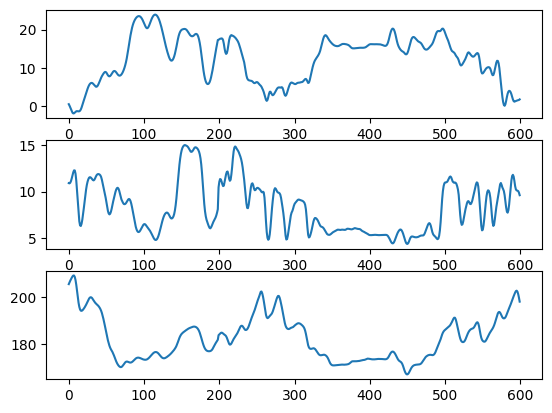

In [ ]:
plot_kinematics(df_tr, 311, signal)


In [ ]:
_ = dt.remove_trials_wo_motion_before_event(df_tr, "idx_motion", "idx_sol_on")


Dropped 135 of 354 rows (38.14%).


Bimodal: True
Dropped 162 of 354 rows (45.76%).


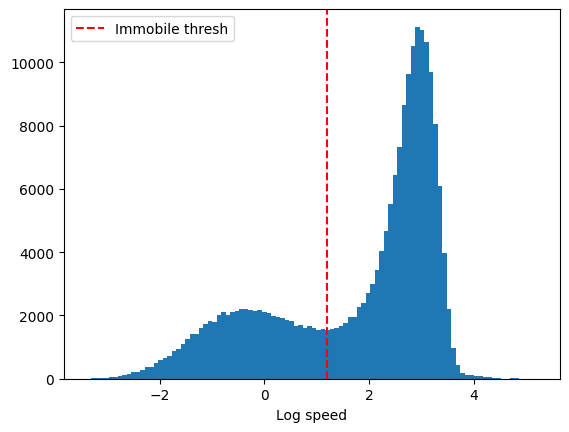

In [ ]:
kin.drop_immobile_trials_from_td(df_tr)


Dropped 135 of 354 rows (38.14%).


100%|██████████| 242/242 [00:03<00:00, 78.07it/s]


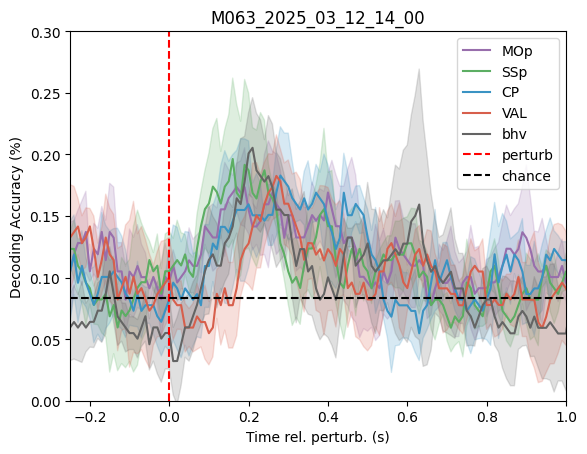

In [ ]:
reports.plot_decoding_sol_dir(df, ["MOp", "SSp", "CP", "VAL"], session)

Bimodal: True
15.856704189236156
Dropped 143 of 354 rows (40.40%).


100%|██████████| 242/242 [00:03<00:00, 73.35it/s]


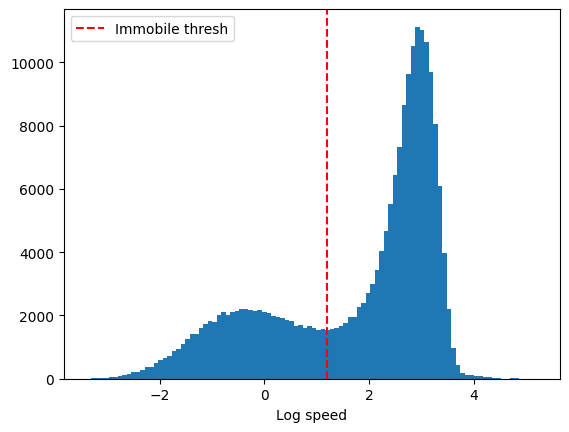

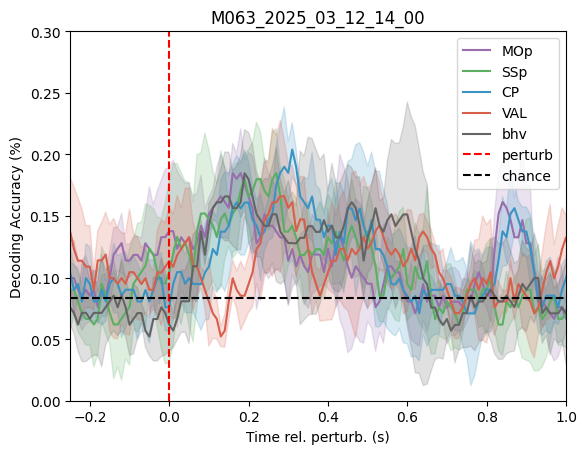

In [ ]:
reports.plot_decoding_sol_dir(df, ["MOp", "SSp", "CP", "VAL"], session)

Bimodal: True
15.856704189236156
Dropped 170 of 354 rows (48.02%).


100%|██████████| 242/242 [00:03<00:00, 76.31it/s]


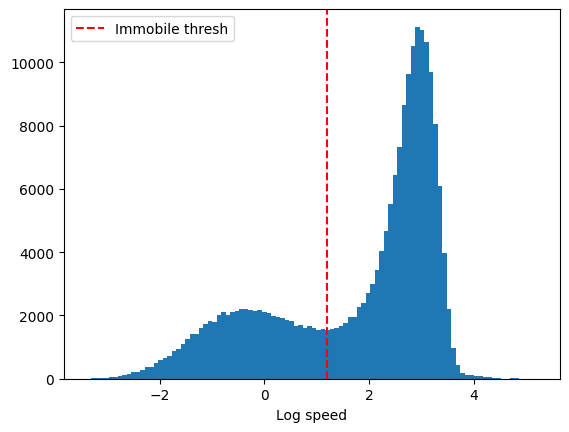

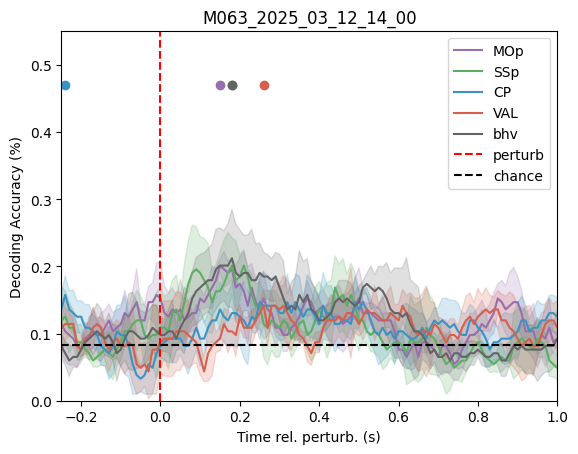

In [ ]:
reports.plot_decoding_sol_dir(df, ["MOp", "SSp", "CP", "VAL"], session)

In [ ]:
df_tr.columns

Index(['animal', 'session', 'trial_id', 'trial_name', 'trial_length',
       'bin_size', 'idx_trial_start', 'idx_trial_end', 'idx_CPI',
       'values_before_camera_trigger', 'idx_before_camera_trigger',
       'idx_motion', 'values_Sol_direction', 'idx_Sol_direction',
       'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on',
       'idx_earthquake_duration', 'idx_session_timer', 'values_MotSen1_X',
       'idx_MotSen1_X', 'values_MotSen1_Y', 'idx_MotSen1_Y', 'hip_center',
       'left_ankle', 'left_ankle_angle', 'left_elbow', 'left_elbow_angle',
       'left_foot', 'left_knee', 'left_knee_angle', 'left_paw',
       'left_shoulder', 'left_wrist', 'left_wrist_angle', 'right_ankle',
       'right_ankle_angle', 'right_elbow', 'right_elbow_angle', 'right_foot',
       'right_knee', 'right_knee_angle', 'right_paw', 'right_shoulder',
       'right_wrist', 'right_wrist_angle', 'shoulder_center', 'tail_base',
       'tail_middle', 'tail_tip', 'SSp_chan_best', 'SSp_unit_guide',
       'SS

In [ ]:
reports.plot_decoding_sol_dir(df, ["MOp", "SSp", "CP", "VAL"], session, p=5)

In [ ]:
vel = np.gradient(np.concatenate(df_tr.bhv.values), axis=0)
speed = np.linalg.norm(vel, axis=1)

In [ ]:
p = 5  # percentile
thr = np.percentile(np.log(speed), p)
thr

0.8246213397656145

Bimodal: False
Dropped 1 of 360 rows (0.28%).


,animal,session,trial_id,trial_name,trial_length,bin_size,idx_trial_start,idx_trial_end,idx_CPI,values_before_camera_trigger,...,CP_kslabel,CP_spikes,SSp_rates,VAL_rates,all_rates,MOp_rates,CP_rates,sol_level_id,sol_contra_ipsi,bhv
0,M063,M063_2025_03_13_14_00,2,trial,600,0.01,48500,49099,[],[],...,"[good, good, good, good, good, good, good, goo...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 11.114692, 14.980366, 2.7606552, 0...","[[0.0, 0.4699854, 14.364602, 13.565235, 14.368...","[[0.0, 28.203657, 17.445675, 9.022838, 0.0, 3....","[[0.0, 0.0, 8.749083, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[4.3722873, 0.010280845, 10.624453, 0.0, 1.23...",1.0,0.0,"[[-3.4818095028531104, 13.583660883822173, 202..."
1,M063,M063_2025_03_13_14_00,4,trial,600,0.01,49400,49999,[],[],...,"[good, good, good, good, good, good, good, goo...","[[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[1.6998556, 0.082790084, 1.2405194, 0.0, 0.00...","[[0.0, 19.159266, 15.566815, 8.150247, 0.0, 1....","[[0.0, 14.163888, 0.0, 17.040775, 16.859224, 1...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.27...","[[0.04294701, 0.0, 32.672085, 0.00012739658, 0...",1.0,1.0,"[[11.590145956254055, 11.337219243864036, 203...."
2,M063,M063_2025_03_13_14_00,6,trial,600,0.01,50100,50699,[],[],...,"[good, good, good, good, good, good, good, goo...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 1.900285, 0.0, 0.00089810096, 0.0,...","[[0.0, 0.0, 10.602128, 3.5599084, 0.023531685,...","[[0.0, 18.306387, 0.27375525, 5.3092546, 14.98...","[[0.0, 15.755326, 0.0, 0.00012739658, 0.0, 0.0...","[[0.004743816, 0.00064846955, 26.87763, 0.0003...",0.0,1.0,"[[7.502754889648802, 12.194520018048587, 204.3..."
3,M063,M063_2025_03_13_14_00,8,trial,600,0.01,51000,51599,[],[],...,"[good, good, good, good, good, good, good, goo...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 10.645076, 10.765961, 0.0021049092, 0.0...","[[0.0, 0.0, 1.4102799, 20.288723, 0.0, 1.69985...","[[0.0, 42.434635, 0.082790084, 10.602128, 14.9...","[[0.0, 0.0021049092, 0.0, 0.0, 0.04294701, 0.0...","[[0.082790084, 14.057439, 27.01087, 0.00300301...",0.0,1.0,"[[-8.097031085407568, 12.724928378998673, 213...."
4,M063,M063_2025_03_13_14_00,10,trial,600,0.01,51700,52299,[],[],...,"[good, good, good, good, good, good, good, goo...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.010280845, 0.04294701, 0.0, 0.0, 4.87...","[[0.0, 16.869505, 0.0, 1.2022661, 9.295875, 20...","[[12.363018, 12.651752, 0.0, 25.725803, 29.005...","[[0.0, 0.021426776, 0.0, 0.0, 14.980366, 12.36...","[[14.344564, 0.0, 1.7067044, 0.030302037, 13.8...",0.0,1.0,"[[-0.7061694651724016, 12.788552051359316, 202..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,M063,M063_2025_03_13_14_00,712,trial,600,0.01,362000,362599,[],[],...,"[good, good, good, good, good, good, good, goo...","[[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0,...","[[0.0, 0.7770648, 0.0, 0.0, 0.0, 22.965147, 8....","[[0.0, 6.548876, 15.255019, 12.363018, 15.1339...","[[0.0, 0.0, 0.0, 0.4696169, 0.0, 3.9026704, 0....","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.7749599, 0.5...","[[0.27375525, 0.0, 0.0, 0.27375525, 0.0, 15.56...",1.0,1.0,"[[10.205973588038091, 12.30402863608021, 186.6..."
356,M063,M063_2025_03_13_14_00,714,trial,600,0.01,363100,363699,[],[],...,"[good, good, good, good, good, good, good, goo...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 2.7709358, 0.0, 0.0, 0.0, 0.004743...","[[0.0, 0.15387057, 9.710159, 0.4696169, 0.0, 0...","[[0.0, 0.0, 0.4696169, 2.7606552, 1.3142953, 1...","[[0.0, 0.0, 0.0, 0.0, 0.00012739658, 0.0, 8.74...","[[5.3083563, 0.0, 0.0, 0.0, 0.0, 0.0, 14.98036...",0.0,1.0,"[[4.160354609455181, 13.17869871854658, 195.42..."
357,M063,M063_2025_03_13_14_00,716,trial,600,0.01,364200,364799,[],[],...,"[good, good, good, good, good, good, good, goo...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 12.365123, 0.00036845426, 0.0, 0.0, 0

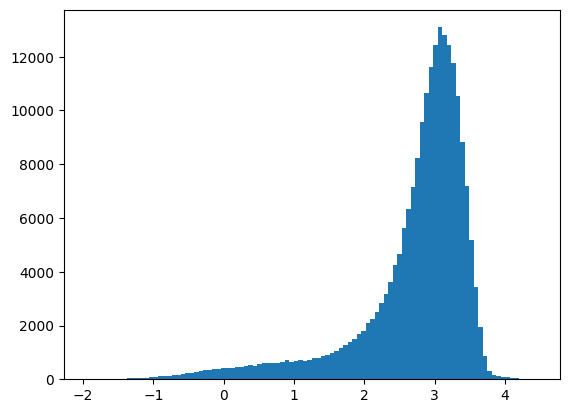

In [ ]:
kin.drop_immobile_trials_from_td(df_tr, p=5)

Bimodal: False
Thresh: 6.68
Dropped 34 of 360 rows (9.44%).


/home/me24/repos/earthquake-analysis/notebooks/testing_stuff/../../tools/reports/quality_control.py:134: UserWarning: Dropping 1 trials because of invalid time indexing. For more information, try warn_per_trial=True
  perturb_td = pyal.restrict_to_interval(td, "idx_sol_on", rel_start=-100, rel_end=150)
100%|██████████| 242/242 [00:03<00:00, 79.64it/s]


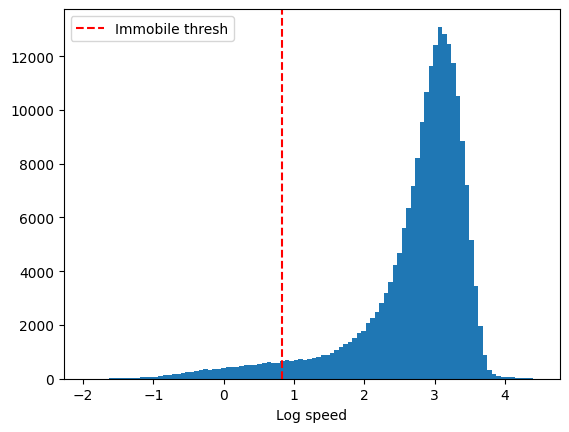

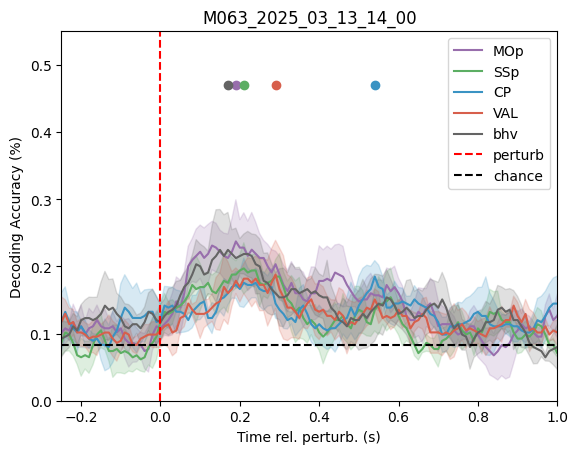

Bimodal: False
Thresh: 10.66
Dropped 45 of 360 rows (12.50%).


/home/me24/repos/earthquake-analysis/notebooks/testing_stuff/../../tools/reports/quality_control.py:134: UserWarning: Dropping 1 trials because of invalid time indexing. For more information, try warn_per_trial=True
  perturb_td = pyal.restrict_to_interval(td, "idx_sol_on", rel_start=-100, rel_end=150)
100%|██████████| 242/242 [00:02<00:00, 81.61it/s]


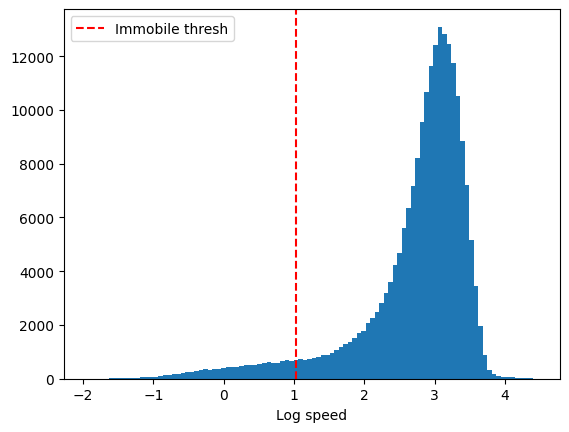

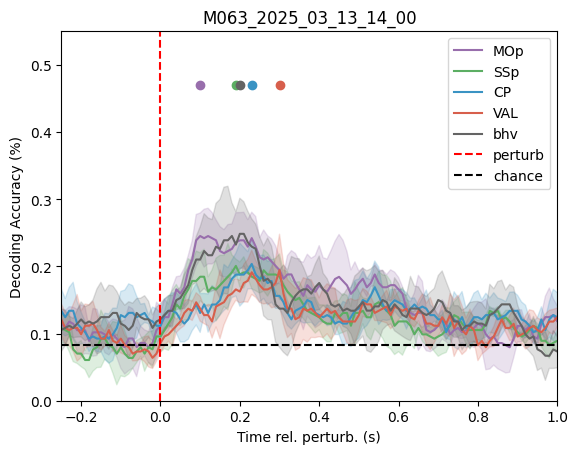

Bimodal: False
Thresh: 16.74
Dropped 62 of 360 rows (17.22%).


/home/me24/repos/earthquake-analysis/notebooks/testing_stuff/../../tools/reports/quality_control.py:134: UserWarning: Dropping 1 trials because of invalid time indexing. For more information, try warn_per_trial=True
  perturb_td = pyal.restrict_to_interval(td, "idx_sol_on", rel_start=-100, rel_end=150)
100%|██████████| 242/242 [00:02<00:00, 82.76it/s]


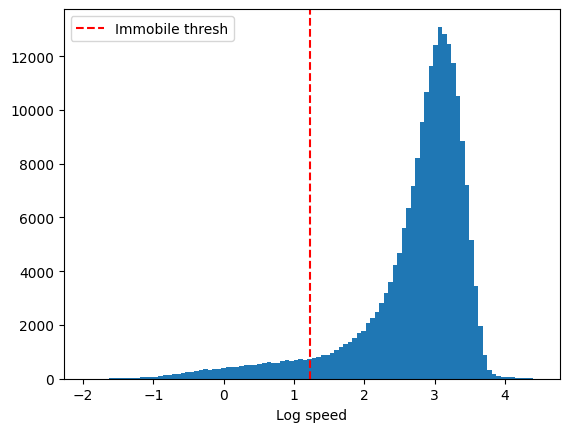

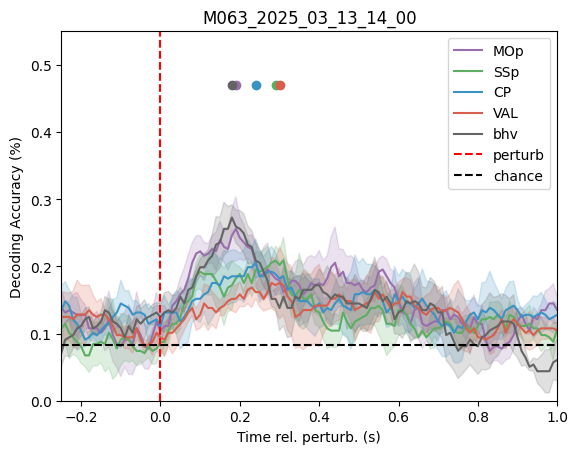

In [ ]:
percentiles = [5, 6, 7]
for p in percentiles:
    reports.plot_decoding_sol_dir(df, ["MOp", "SSp", "CP", "VAL"], session, p=p)
    plt.show()

In [5]:
print(1)

1


In [2]:
sessions = [
    # 'M061_2025_03_04_10_00',
    # 'M061_2025_03_05_14_00',
    # 'M061_2025_03_06_14_00',
    # 'M063_2025_03_12_14_00',
    # 'M063_2025_03_13_14_00',
    # 'M063_2025_03_14_15_30',
    # 'M062_2025_03_19_14_00',
    # 'M062_2025_03_20_14_00',
    # 'M062_2025_03_21_14_00',
    # 'M078_2025_08_05_15_30',
    # 'M078_2025_08_06_15_00',
    # 'M078_2025_08_07_13_30',
    # 'M078_2025_08_08_10_30',
    # 'M086_2025_12_09_16_00'
    'M086_2025_12_10_15_00'

]

for session in sessions:
    data_dir='/data/bnd-data/raw/'
    combine_time_bins=False

    df = pyal.load_pyaldata(data_dir + session[:4] + "/" + session)
    df = dsp.preprocess(df, only_trials=False, combine_time_bins=combine_time_bins)
    df = dt.add_bhv(df)
    # df_tr = pyal.select_trials(df, df.trial_name == 'trial')
    # vel = np.gradient(np.concatenate(df_tr.bhv.values), axis=0)
    # speed = np.linalg.norm(vel, axis=1)  

    # kin.drop_immobile_trials_from_td(df_tr, win=40, p=2)
    # reports.plot_decoding_sol_dir(df, ["MOp", "MOs", "CP", "VAL", "SSp"], session, p=2)



fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_direction', 'values_Sol_duration'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_direction', 'idx_Sol_direction', 'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_direction', 'idx_Sol_direction', 'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on'] could not be converted to int.
['MOp_spikes', 'all_spikes', 'CP_spikes', 'SSp_spikes', 'VAL_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of MOp_spikes on 99.85875706214689% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of MOp_spikes on 99.85875706214689% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of MOp_spikes on 99.85875706214689% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of MOp_spikes on 99.85875706214689% of trials
  warnings.warn(


Resulting MOp_spikes ephys data shape is (NxT): (199, 48000)
Resulting all_spikes ephys data shape is (NxT): (96, 48000)
Resulting CP_spikes ephys data shape is (NxT): (199, 48000)
Resulting SSp_spikes ephys data shape is (NxT): (149, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (72, 48000)


d: 0.896
Bimodal: False
Thresh: 45.18
Dropped 17 of 353 rows (4.82%).


100%|██████████| 242/242 [00:04<00:00, 50.58it/s]


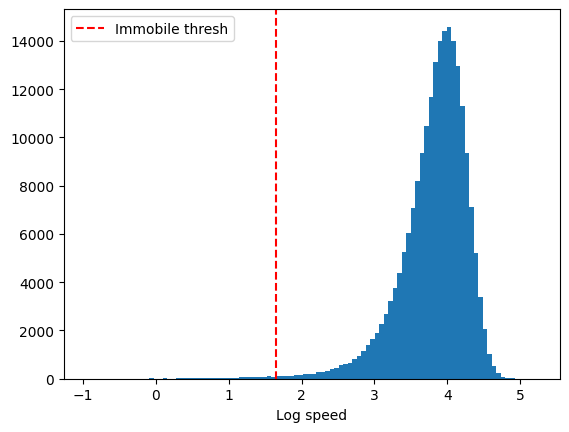

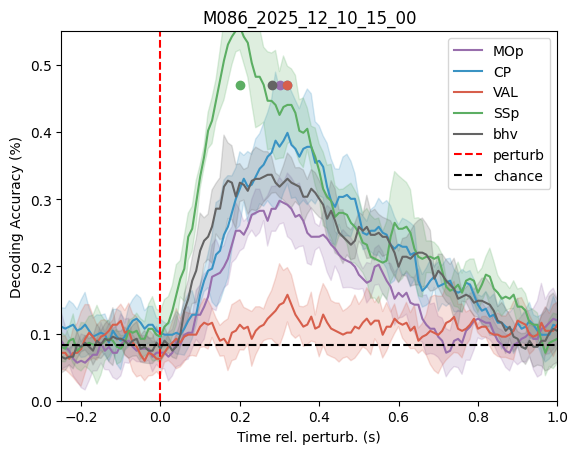

d: 0.896
Bimodal: False
Thresh: 60.35
Dropped 24 of 353 rows (6.80%).


100%|██████████| 242/242 [00:05<00:00, 46.37it/s]


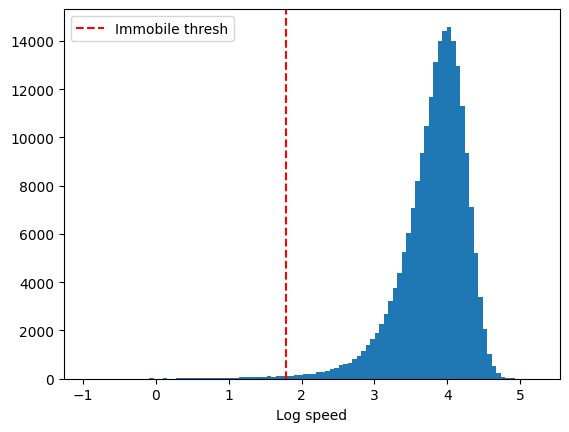

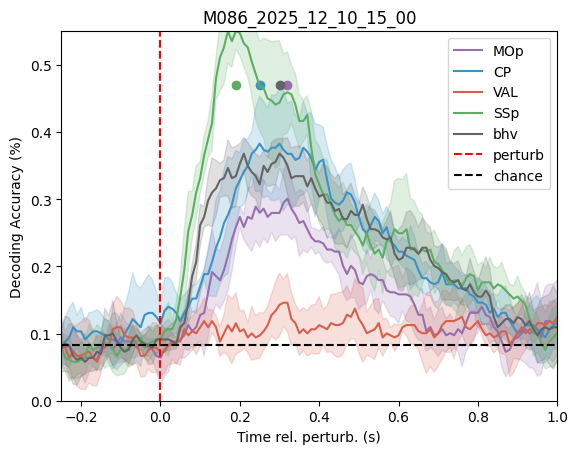

In [4]:
percentiles = [0.5, 0.6]
for p in percentiles:
    reports.plot_decoding_sol_dir(df, ["MOp", "CP", "VAL", "SSp"], session, p=p)
    plt.show()

No behaviour found
Dropped 295 of 499 rows (59.12%).


100%|██████████| 242/242 [00:05<00:00, 46.60it/s]


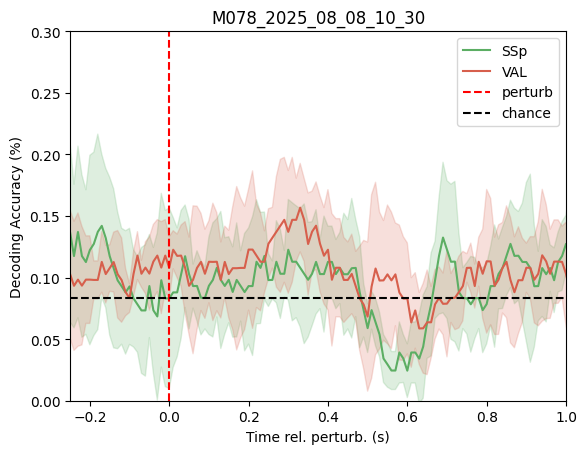

In [ ]:
percentiles = [2]
for p in percentiles:
    reports.plot_decoding_sol_dir(df, ["SSp", "VAL"], session, p=p)
    plt.show()